<a href="https://colab.research.google.com/github/Fedekasparian/Sistemas-inteligentes/blob/main/Notebook_AIyLLM_02_ANN_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red neuronal de dos capas

Esta notebook implementa, una red neuronal de dos capas para la resolución de una función no lineal.

Importamos las librerías necesarias:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

## Red neuronal de dos capas

A continuación se plantea una red neuronal con una capa oculta para resolver el XOR:

In [ ]:
# Datos del problema XOR
data = {
    "Variable 1": [0, 0, 1, 1],
    "Variable 2": [0, 1, 0, 1],
    "Salida Esperada": [0, 1, 1, 0]  # XOR lógico
}

df = pd.DataFrame(data)

Se separan en entradas y salidas:

In [ ]:
# Entradas (X) y salidas (y)
X = df[["Variable 1", "Variable 2"]].values  # Matriz de entrada
y = df["Salida Esperada"].values  # Vector de salida

Se definen las entradas, la capa oculta, el modelo y las salidas y se compila el modelo:

In [ ]:
# Definir el modelo de red neuronal con una capa oculta
inputs = tf.keras.Input(shape=(2,))  # Dos variables de entrada
capa_oculta = tf.keras.layers.Dense(8, activation='relu')(inputs)  # Aumentar a 8 neuronas
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(capa_oculta)  # Capa de salida
modelo = tf.keras.Model(inputs=inputs, outputs=outputs)  # Crear el modelo

# Compilar el modelo
modelo.compile(optimizer='adam',
               loss='binary_crossentropy',  # Pérdida para clasificación binaria
               metrics=['accuracy'])

In [ ]:
# Entrenar el modelo
historial = modelo.fit(X, y, epochs=1000, verbose=0)

In [ ]:
# Obtener predicciones del modelo
y_pred = modelo.predict(X)

# Convertir predicciones a clases binarias (umbral 0.5)
predicciones_binarias = (y_pred.flatten() >= 0.5).astype(int)

# Calcular el accuracy
accuracy = (y == predicciones_binarias).mean()
print(f"Accuracy: {accuracy * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Accuracy: 100.00%


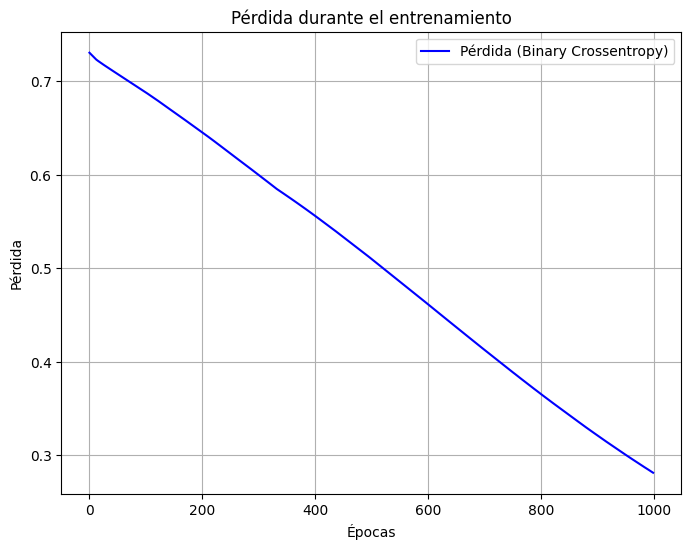

In [ ]:
# Graficar la pérdida durante el entrenamiento
plt.figure(figsize=(8, 6))
plt.plot(historial.history['loss'], label='Pérdida (Binary Crossentropy)', color='blue')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Predicciones finales
y_pred = modelo.predict(X)

# Mostrar resultados
print("Resultados del modelo:")
for entrada, prediccion, salida_real in zip(X, y_pred, y):
    print(f"Entrada: {entrada}, Predicción: {prediccion[0]:.2f}, Salida Real: {salida_real}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Resultados del modelo:
Entrada: [0 0], Predicción: 0.27, Salida Real: 0
Entrada: [0 1], Predicción: 0.76, Salida Real: 1
Entrada: [1 0], Predicción: 0.77, Salida Real: 1
Entrada: [1 1], Predicción: 0.23, Salida Real: 0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


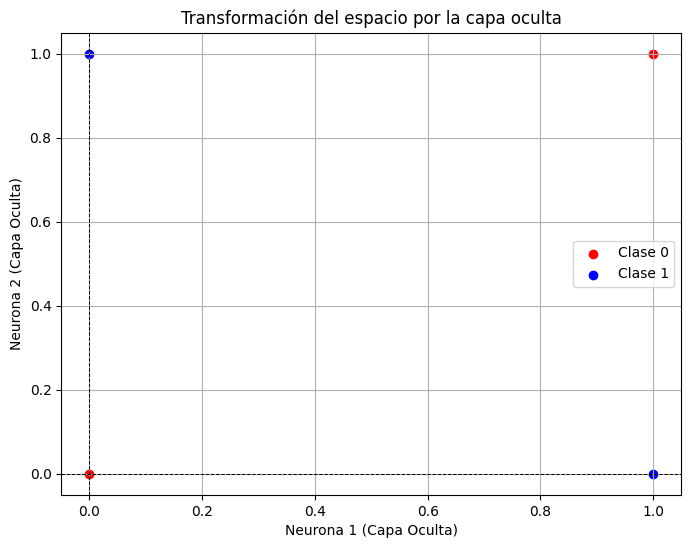

In [ ]:
# Visualizar la transformación del espacio en la capa oculta
capa_oculta_modelo = tf.keras.Model(inputs=modelo.input, outputs=modelo.layers[0].output)
transformacion = capa_oculta_modelo.predict(tf.convert_to_tensor(X))

plt.figure(figsize=(8, 6))
for i, label in enumerate(y):
    color = 'blue' if label == 1 else 'red'
    plt.scatter(transformacion[i, 0], transformacion[i, 1], color=color, label=f'Clase {int(label)}' if i < 2 else "")

plt.title("Transformación del espacio por la capa oculta")
plt.xlabel("Neurona 1 (Capa Oculta)")
plt.ylabel("Neurona 2 (Capa Oculta)")
plt.axhline(0, color="black", linestyle="--", linewidth=0.7)
plt.axvline(0, color="black", linestyle="--", linewidth=0.7)
plt.grid()
plt.legend()
plt.show()

Pesos aprendidos (capa oculta):
[[ 1.3174897  -0.2953018   1.1624305   0.3868536   0.737493   -0.51349044
   0.47416776  0.27987328]
 [ 1.088391   -0.65466166 -1.1628122   1.3461007   0.7375139   0.00190834
   1.1677319  -0.7644562 ]]

Bias aprendidos (capa oculta):
[-1.0885584e+00  0.0000000e+00  1.3547056e-04  4.8671744e-04
 -7.3743510e-01 -2.2913709e-02  4.8021963e-04 -2.9537901e-01]


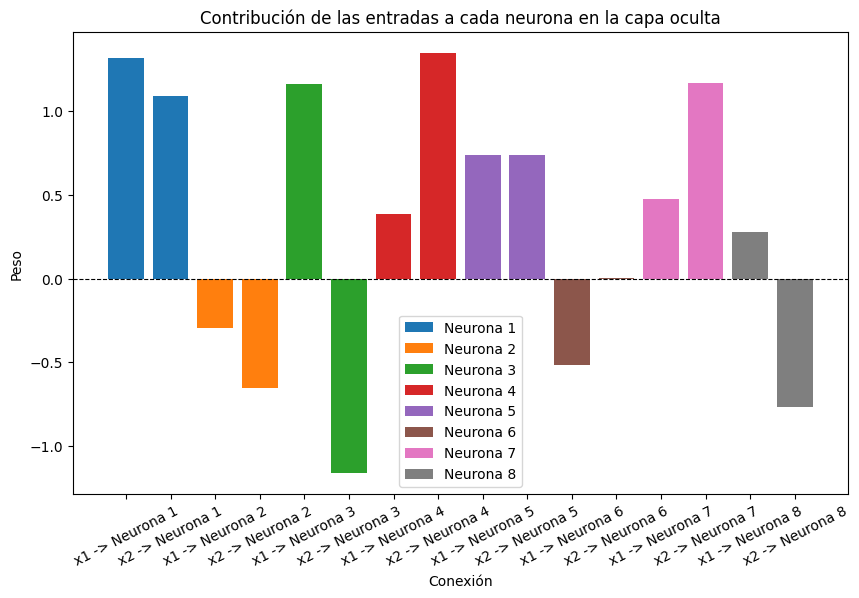

In [ ]:
# Obtener los pesos y bias de la capa oculta
pesos_capa_oculta, bias_capa_oculta = modelo.layers[1].get_weights()

# Mostrar los pesos y bias aprendidos
print("Pesos aprendidos (capa oculta):")
print(pesos_capa_oculta)
print("\nBias aprendidos (capa oculta):")
print(bias_capa_oculta)

# Visualizar los pesos de cada neurona
import matplotlib.pyplot as plt
num_neuronas = pesos_capa_oculta.shape[1]  # Número de neuronas en la capa oculta

# Visualizar los pesos con una orientación en las etiquetas para evitar que se pisen
plt.figure(figsize=(10, 6))
for i in range(num_neuronas):
    plt.bar([f'x1 -> Neurona {i+1}', f'x2 -> Neurona {i+1}'],
            pesos_capa_oculta[:, i],
            label=f'Neurona {i+1}')

plt.title("Contribución de las entradas a cada neurona en la capa oculta")
plt.ylabel("Peso")
plt.xlabel("Conexión")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=27)  # Rotar las etiquetas 27 grados
plt.legend()
plt.show()

